In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
url = "https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv"
apple = pd.read_csv(url)

In [27]:
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


In [28]:
apple.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object

In [29]:
apple['Date'] = pd.to_datetime(apple['Date'])

In [30]:
apple = apple.set_index('Date')

In [31]:
apple.index.duplicated().sum()

np.int64(0)

In [32]:
apple = apple.sort_index()

In [33]:
apple

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-12,28.75,28.87,28.75,28.75,117258400,0.45
1980-12-15,27.38,27.38,27.25,27.25,43971200,0.42
1980-12-16,25.37,25.37,25.25,25.25,26432000,0.39
1980-12-17,25.87,26.00,25.87,25.87,21610400,0.40
1980-12-18,26.63,26.75,26.63,26.63,18362400,0.41
...,...,...,...,...,...,...
2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52
2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03


In [34]:
last_date = apple.groupby(pd.Grouper(freq='BM')).last()

C:\Users\salmaa\AppData\Local\Temp\ipykernel_10680\2825718727.py:1: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  last_date = apple.groupby(pd.Grouper(freq='BM')).last()


In [35]:
print(last_date)

              Open    High     Low   Close     Volume  Adj Close
Date                                                            
1980-12-31   34.25   34.25   34.13   34.13    8937600       0.53
1981-01-30   28.50   28.50   28.25   28.25   11547200       0.44
1981-02-27   26.50   26.75   26.50   26.50    3690400       0.41
1981-03-31   24.75   24.75   24.50   24.50    3998400       0.38
1981-04-30   28.38   28.62   28.38   28.38    3152800       0.44
...            ...     ...     ...     ...        ...        ...
2014-03-31  539.23  540.81  535.93  536.74   42167300      76.25
2014-04-30  592.64  599.43  589.80  590.09  114160200      83.83
2014-05-30  637.98  644.17  628.90  633.00  141005200      90.43
2014-06-30   92.10   93.73   92.09   92.93   49482300      92.93
2014-07-31   96.27   96.80   93.92   95.35   65130000      95.35

[404 rows x 6 columns]


In [36]:
diff = apple.index.max() - apple.index.min()
print(diff)

12261 days 00:00:00


In [37]:
months = apple.index.to_period('M').nunique()

In [38]:
months

404

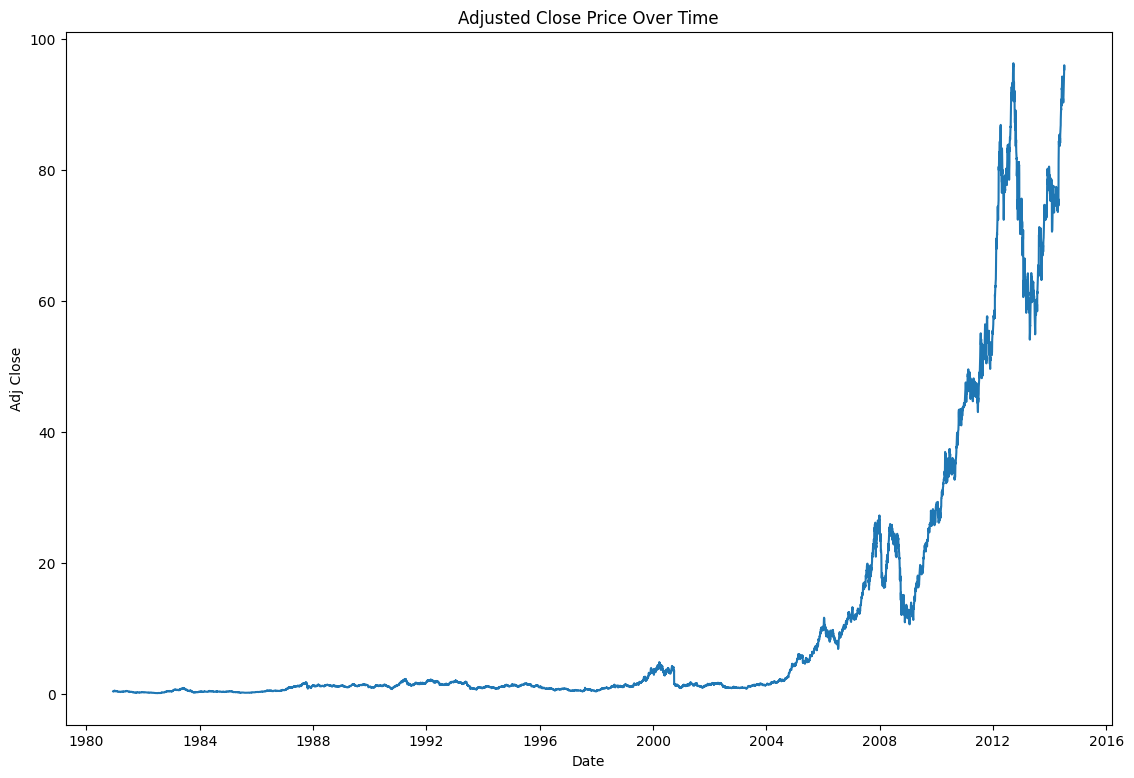

In [ ]:
plt.figure(figsize=(13.5, 9))
plt.plot(apple['Adj Close'])
plt.title("Adjusted Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.show()